# 02 — 数据采样误差与简化硬件噪声

这一章用小型密度矩阵模拟展示 QOS 的关键权衡：

$$
\epsilon_{\rm total}(M)
\approx
\frac{aN}{M}
+bM p_{\rm gate}
+\epsilon_{\rm readout}.
$$

更多经典样本能降低 QOS 采样误差，却会生成更长的线路并积累硬件误差。

这里的模型是用于理解趋势的简化模型，不是某一台 Quafu-SQC 芯片的
calibrated noise model。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260728

In [2]:
def parity_function(n_address):
    return np.array(
        [x.bit_count() % 2 for x in range(2**n_address)],
        dtype=np.int8,
    )


def hadamard_n(n_address):
    h1 = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
    result = np.array([[1]], dtype=complex)
    for _ in range(n_address):
        result = np.kron(result, h1)
    return result


def apply_local_phase_flip(rho, n_address, probability):
    if probability == 0:
        return rho
    if not 0 <= probability <= 1:
        raise ValueError("phase-flip probability must be in [0, 1].")

    indices = np.arange(rho.shape[0])
    updated = rho
    for bit in range(n_address):
        z_sign = 1 - 2 * ((indices >> bit) & 1)
        z_rho_z = z_sign[:, None] * updated * z_sign[None, :]
        updated = (1 - probability) * updated + probability * z_rho_z
    return updated


def apply_symmetric_readout_error(probabilities, n_address, probability):
    if probability == 0:
        return probabilities.copy()

    n_states = len(probabilities)
    observed = np.zeros_like(probabilities)
    for true_state, true_prob in enumerate(probabilities):
        for measured_state in range(n_states):
            distance = (true_state ^ measured_state).bit_count()
            transition = (
                probability**distance
                * (1 - probability) ** (n_address - distance)
            )
            observed[measured_state] += true_prob * transition
    return observed


def simulate_one_stream(
    f_values,
    num_samples,
    rng,
    *,
    relative_angle_bias=0.0,
    angle_jitter_std=0.0,
    phase_flip_per_sample=0.0,
    readout_flip=0.0,
):
    n_states = len(f_values)
    n_address = int(np.log2(n_states))
    if 2**n_address != n_states:
        raise ValueError("f_values length must be a power of two.")

    plus = np.ones(n_states, dtype=complex) / np.sqrt(n_states)
    rho = np.outer(plus, plus.conj())
    stream = rng.integers(0, n_states, size=num_samples)
    ideal_single_angle = np.pi * n_states / num_samples

    for address in stream:
        if f_values[address]:
            actual_angle = (
                ideal_single_angle * (1 + relative_angle_bias)
                + rng.normal(0.0, angle_jitter_std)
            )
            diagonal = np.ones(n_states, dtype=complex)
            diagonal[address] = np.exp(1j * actual_angle)
            rho = diagonal[:, None] * rho * diagonal.conj()[None, :]

        # 用每个流样本的一次小通道表示线路/等待期间的相干损失。
        rho = apply_local_phase_flip(
            rho, n_address, phase_flip_per_sample
        )

    exact_inverse = np.exp(-1j * np.pi * f_values)
    rho = (
        exact_inverse[:, None]
        * rho
        * exact_inverse.conj()[None, :]
    )

    h_all = hadamard_n(n_address)
    rho = h_all @ rho @ h_all.conj().T
    probabilities = np.real_if_close(np.diag(rho)).real
    probabilities = np.clip(probabilities, 0.0, None)
    probabilities /= probabilities.sum()
    observed = apply_symmetric_readout_error(
        probabilities, n_address, readout_flip
    )

    return float(probabilities[0]), float(observed[0])

## 扫描 $M$

四条曲线分别隔离：

- 纯 QOS 采样误差；
- 固定 2% 相位过旋；
- 随流样本数积累的相位翻转；
- 相位翻转再加 1% 对称读出错误。

In [3]:
n_address = 3
f_values = parity_function(n_address)
n_states = len(f_values)
sample_sizes = n_states * 2 ** np.arange(0, 7)
R_STREAMS = 80

scenarios = {
    "ideal sampling": {},
    "2% coherent over-rotation": {
        "relative_angle_bias": 0.02,
    },
    "phase flip per sample": {
        "phase_flip_per_sample": 2e-4,
    },
    "phase flip + 1% readout": {
        "phase_flip_per_sample": 2e-4,
        "readout_flip": 0.01,
    },
}

rows = []
master_rng = np.random.default_rng(SEED)

for scenario_name, parameters in scenarios.items():
    for num_samples in sample_sizes:
        stream_seeds = master_rng.integers(
            0, 2**63 - 1, size=R_STREAMS
        )
        expected_success = []
        observed_success = []

        for stream_seed in stream_seeds:
            stream_rng = np.random.default_rng(stream_seed)
            expected, observed = simulate_one_stream(
                f_values,
                int(num_samples),
                stream_rng,
                **parameters,
            )
            expected_success.append(expected)
            observed_success.append(observed)

        success = np.asarray(observed_success)
        infidelity = 1 - success
        rows.append(
            {
                "scenario": scenario_name,
                "M_data": int(num_samples),
                "R_streams": R_STREAMS,
                "mean_infidelity": infidelity.mean(),
                "ci95": 1.96
                * infidelity.std(ddof=1)
                / np.sqrt(R_STREAMS),
                "mean_pre_readout_F": np.mean(expected_success),
            }
        )

noise_sweep = pd.DataFrame(rows)
display(noise_sweep.head(12))

,scenario,M_data,R_streams,mean_infidelity,ci95,mean_pre_readout_F
0,ideal sampling,8,80,0.767969,0.051716,0.232031
1,ideal sampling,16,80,0.658594,0.045682,0.341406
2,ideal sampling,32,80,0.499123,0.043299,0.500877
3,ideal sampling,64,80,0.329744,0.040034,0.670256
4,ideal sampling,128,80,0.216751,0.029557,0.783249
5,ideal sampling,256,80,0.110818,0.015794,0.889182
6,ideal sampling,512,80,0.063262,0.011475,0.936738
7,2% coherent over-rotation,8,80,0.734218,0.052908,0.265782
8,2% coherent over-rotation,16,80,0.675223,0.043463,0.324777
9,2% coherent over-rotation,32,80,0.510608,0.041191,0.489392


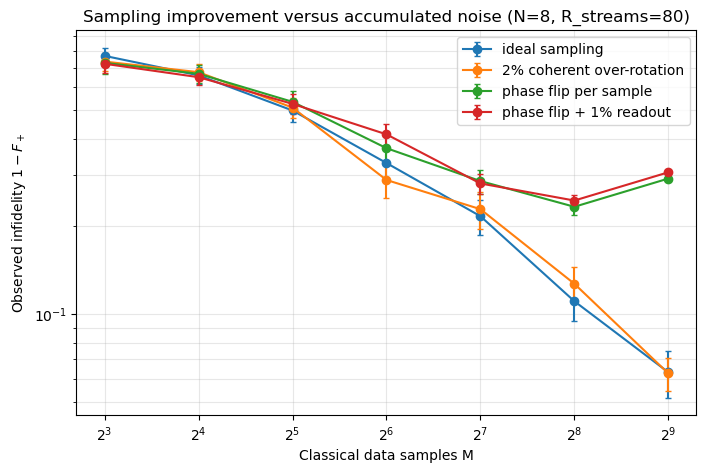

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

for scenario_name in scenarios:
    subset = noise_sweep[noise_sweep["scenario"] == scenario_name]
    ax.errorbar(
        subset["M_data"],
        subset["mean_infidelity"],
        yerr=subset["ci95"],
        marker="o",
        capsize=2,
        label=scenario_name,
    )

ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set(
    xlabel="Classical data samples M",
    ylabel=r"Observed infidelity $1-F_+$",
    title=(
        f"Sampling improvement versus accumulated noise "
        f"(N={n_states}, R_streams={R_STREAMS})"
    ),
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

In [5]:
optimum_rows = []
for scenario_name in scenarios:
    subset = noise_sweep[noise_sweep["scenario"] == scenario_name]
    best = subset.loc[subset["mean_infidelity"].idxmin()]
    optimum_rows.append(
        {
            "scenario": scenario_name,
            "empirical_M_opt": int(best["M_data"]),
            "minimum_mean_infidelity": best["mean_infidelity"],
        }
    )

display(pd.DataFrame(optimum_rows))

,scenario,empirical_M_opt,minimum_mean_infidelity
0,ideal sampling,512,0.063262
1,2% coherent over-rotation,512,0.062717
2,phase flip per sample,256,0.233455
3,phase flip + 1% readout,256,0.245235


## 区分 between-stream variance 和 finite-shot variance

固定 $M$ 后，先生成多条独立数据流，再对每条线路模拟 1024 shots。
两层波动不能简单混成一个样本集合。

In [6]:
M_DATA = 8 * n_states
S_SHOTS = 1024
K_VARIANCE = 300
variance_rng = np.random.default_rng(SEED + 1)

true_probabilities = np.array(
    [
        simulate_one_stream(
            f_values,
            M_DATA,
            np.random.default_rng(
                variance_rng.integers(0, 2**63 - 1)
            ),
        )[0]
        for _ in range(K_VARIANCE)
    ]
)
shot_estimates = variance_rng.binomial(
    S_SHOTS, true_probabilities
) / S_SHOTS

variance_summary = pd.DataFrame(
    {
        "quantity": [
            "between-stream std of true F",
            "std after finite shots",
            "mean conditional binomial std",
        ],
        "value": [
            true_probabilities.std(ddof=1),
            shot_estimates.std(ddof=1),
            np.mean(
                np.sqrt(
                    true_probabilities
                    * (1 - true_probabilities)
                    / S_SHOTS
                )
            ),
        ],
    }
)
display(variance_summary)
print(
    f"Reported hierarchy: K={K_VARIANCE}, "
    f"M_data={M_DATA}, S_shots={S_SHOTS}"
)

,quantity,value
0,between-stream std of true F,0.178093
1,std after finite shots,0.179211
2,mean conditional binomial std,0.013500


Reported hierarchy: K=300, M_data=64, S_shots=1024


### 解释限制

- `phase_flip_per_sample` 是教学用通道，不是芯片校准参数；
- 当前没有模拟 amplitude damping、crosstalk、路由和编译差异；
- 真机实验需要从 `result['transpiled']` 统计实际门数；
- 经验 $M_{\rm opt}$ 只对当前函数、噪声参数和验证输入成立。